#  Решение задачи классификации при помощи пакета `torch`.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://lightning.ai/docs/torchmetrics/stable/
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://www.learnpytorch.io/02_pytorch_classification/
* https://pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler
* https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb45
* https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
* https://medium.com/@zergtant/use-weighted-loss-function-to-solve-imbalanced-data-classification-problems-749237f38b7
* https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html#torch.nn.BCELoss
* https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html#torch.nn.BCEWithLogitsLoss52

## Задачи для совместного разбора

In [1]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th

Scalar = TensorType[()]
patch_typeguard()

1\. Обсудите подходы к решению задачи классификации на примере синтетического датасета.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу классификации. Разделите датасет на обучающую и тестовую выборку в соотношении 80% на 20%. В качестве функции потерь используйте реализацию `CrossEntropyLoss` из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. 

Используйте модель, состоящую из двух слоев:
1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 2 нейронами.

Выведите график изменения значения функции потерь в процессе обучения. Выведите на экран значения Accuracy, Precision, Recall и F1 для обучающего и тестового множества. 

Выведите на экран облако точек с цветом, соответствующим предсказаниям модели на всем датасете (и обучающей, и тестовой части). 

- [ ] Проверено на семинаре 


In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X = th.FloatTensor(X)
y = th.LongTensor(y)

Train metrics:
Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1: 0.6666666666666666

Test metrics:
Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1: 0.6666666666666666


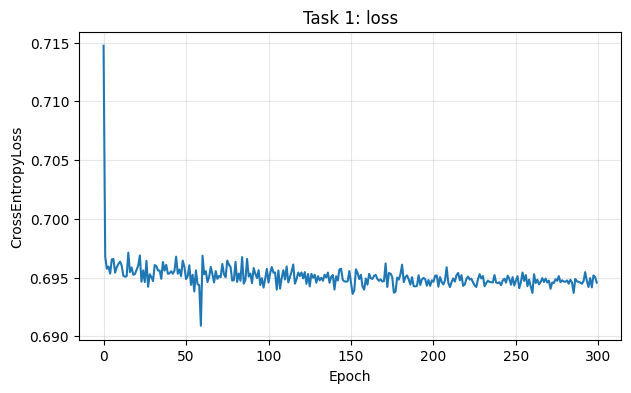

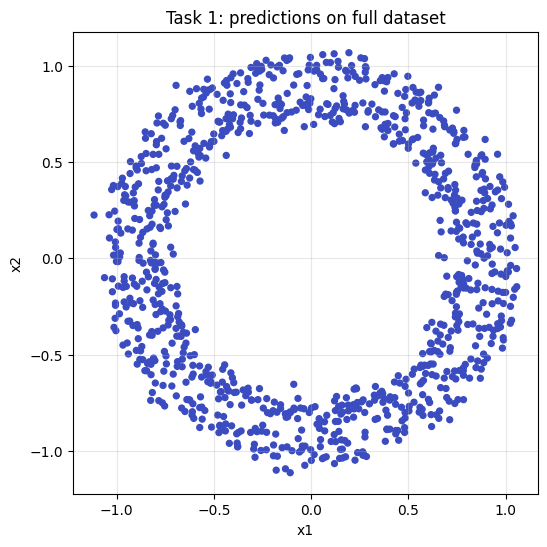

In [3]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.2, random_state=42, stratify=y.numpy()
 )
X_train = th.tensor(X_train, dtype=th.float32)
X_test = th.tensor(X_test, dtype=th.float32)
y_train = th.tensor(y_train, dtype=th.long)
y_test = th.tensor(y_test, dtype=th.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

model1 = nn.Sequential(
    nn.Linear(2, 10),
    nn.Linear(10, 2),
)
criterion = nn.CrossEntropyLoss()
optimizer = th.optim.SGD(model1.parameters(), lr=0.1)

epochs = 300
loss_history = []
for _ in range(epochs):
    model1.train()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model1(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    loss_history.append(epoch_loss / n_batches)

model1.eval()
with th.no_grad():
    train_pred = model1(X_train).argmax(dim=1)
    test_pred = model1(X_test).argmax(dim=1)
    all_pred = model1(X).argmax(dim=1)

print('Train metrics:')
print('Accuracy:', accuracy_score(y_train.numpy(), train_pred.numpy()))
print('Precision:', precision_score(y_train.numpy(), train_pred.numpy()))
print('Recall:', recall_score(y_train.numpy(), train_pred.numpy()))
print('F1:', f1_score(y_train.numpy(), train_pred.numpy()))

print('\nTest metrics:')
print('Accuracy:', accuracy_score(y_test.numpy(), test_pred.numpy()))
print('Precision:', precision_score(y_test.numpy(), test_pred.numpy()))
print('Recall:', recall_score(y_test.numpy(), test_pred.numpy()))
print('F1:', f1_score(y_test.numpy(), test_pred.numpy()))

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title('Task 1: loss')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropyLoss')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=all_pred.numpy(), s=18, cmap='coolwarm')
plt.title('Task 1: predictions on full dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(alpha=0.3)
plt.show()

<p class="task" id="2"></p>

2\. Повторите задачу 1, используя другую архитектуру нейронной сети.

1. Полносвязный слой с 10 нейронами;
2. Функция активации ReLU;
3. Полносвязный слой с 2 нейронами.

- [ ] Проверено на семинаре

Train metrics:
Accuracy: 0.975
Precision: 0.9773869346733668
Recall: 0.9725
F1: 0.974937343358396

Test metrics:
Accuracy: 0.985
Precision: 0.9801980198019802
Recall: 0.99
F1: 0.9850746268656716


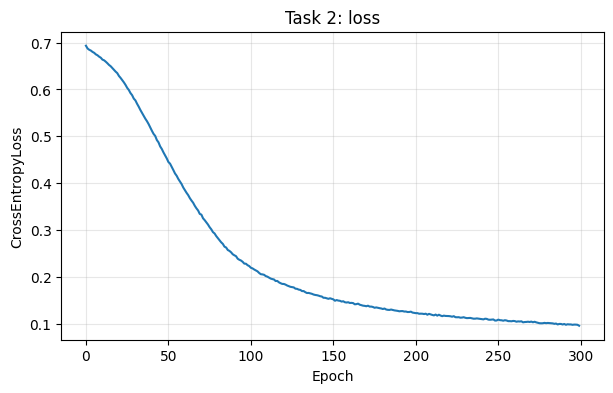

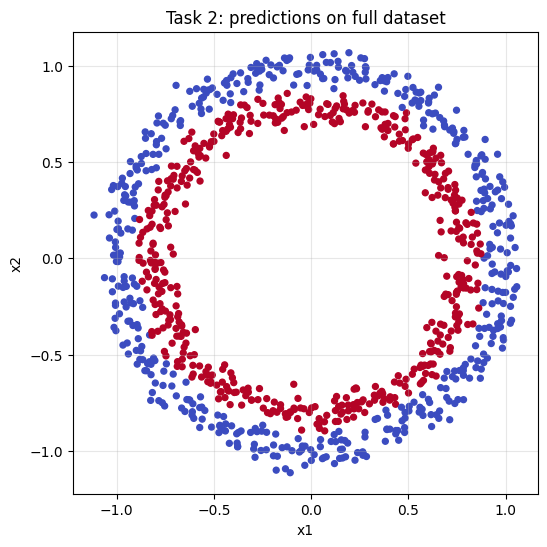

In [4]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.2, random_state=42, stratify=y.numpy()
 )
X2_train = th.tensor(X2_train, dtype=th.float32)
X2_test = th.tensor(X2_test, dtype=th.float32)
y2_train = th.tensor(y2_train, dtype=th.long)
y2_test = th.tensor(y2_test, dtype=th.long)

train_loader2 = DataLoader(TensorDataset(X2_train, y2_train), batch_size=32, shuffle=True)

model2 = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 2),
)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = th.optim.SGD(model2.parameters(), lr=0.1)

epochs2 = 300
loss_history2 = []
for _ in range(epochs2):
    model2.train()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader2:
        optimizer2.zero_grad()
        logits = model2(xb)
        loss = criterion2(logits, yb)
        loss.backward()
        optimizer2.step()
        epoch_loss += loss.item()
        n_batches += 1
    loss_history2.append(epoch_loss / n_batches)

model2.eval()
with th.no_grad():
    train2_pred = model2(X2_train).argmax(dim=1)
    test2_pred = model2(X2_test).argmax(dim=1)
    all2_pred = model2(X).argmax(dim=1)

print('Train metrics:')
print('Accuracy:', accuracy_score(y2_train.numpy(), train2_pred.numpy()))
print('Precision:', precision_score(y2_train.numpy(), train2_pred.numpy()))
print('Recall:', recall_score(y2_train.numpy(), train2_pred.numpy()))
print('F1:', f1_score(y2_train.numpy(), train2_pred.numpy()))

print('\nTest metrics:')
print('Accuracy:', accuracy_score(y2_test.numpy(), test2_pred.numpy()))
print('Precision:', precision_score(y2_test.numpy(), test2_pred.numpy()))
print('Recall:', recall_score(y2_test.numpy(), test2_pred.numpy()))
print('F1:', f1_score(y2_test.numpy(), test2_pred.numpy()))

plt.figure(figsize=(7, 4))
plt.plot(loss_history2)
plt.title('Task 2: loss')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropyLoss')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=all2_pred.numpy(), s=18, cmap='coolwarm')
plt.title('Task 2: predictions on full dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(alpha=0.3)
plt.show()

<p class="task" id="3"></p>

3\. `CrossEntropyLoss` может быть использована для задачи классификации на любое количество классов. Для задачи бинарной классификации существуют специфические функции потерь. Решите задачу 2, используя `BCEWithLogitsLoss` в качестве функции потерь.

- [ ] Проверено на семинаре

In [5]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.2, random_state=42, stratify=y.numpy()
 )
X3_train = th.tensor(X3_train, dtype=th.float32)
X3_test = th.tensor(X3_test, dtype=th.float32)
y3_train = th.tensor(y3_train, dtype=th.float32).view(-1, 1)
y3_test = th.tensor(y3_test, dtype=th.float32).view(-1, 1)

train_loader3 = DataLoader(TensorDataset(X3_train, y3_train), batch_size=32, shuffle=True)

model3 = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
)
criterion3 = nn.BCEWithLogitsLoss()
optimizer3 = th.optim.SGD(model3.parameters(), lr=0.1)

epochs3 = 300
for _ in range(epochs3):
    model3.train()
    for xb, yb in train_loader3:
        optimizer3.zero_grad()
        logits = model3(xb)
        loss = criterion3(logits, yb)
        loss.backward()
        optimizer3.step()

model3.eval()
with th.no_grad():
    train3_prob = th.sigmoid(model3(X3_train))
    test3_prob = th.sigmoid(model3(X3_test))
    train3_pred = (train3_prob >= 0.5).long().view(-1)
    test3_pred = (test3_prob >= 0.5).long().view(-1)

print('Train metrics:')
print('Accuracy:', accuracy_score(y3_train.view(-1).numpy(), train3_pred.numpy()))
print('Precision:', precision_score(y3_train.view(-1).numpy(), train3_pred.numpy()))
print('Recall:', recall_score(y3_train.view(-1).numpy(), train3_pred.numpy()))
print('F1:', f1_score(y3_train.view(-1).numpy(), train3_pred.numpy()))

print('\nTest metrics:')
print('Accuracy:', accuracy_score(y3_test.view(-1).numpy(), test3_pred.numpy()))
print('Precision:', precision_score(y3_test.view(-1).numpy(), test3_pred.numpy()))
print('Recall:', recall_score(y3_test.view(-1).numpy(), test3_pred.numpy()))
print('F1:', f1_score(y3_test.view(-1).numpy(), test3_pred.numpy()))

Train metrics:
Accuracy: 0.95375
Precision: 0.9270588235294117
Recall: 0.985
F1: 0.9551515151515152

Test metrics:
Accuracy: 0.965
Precision: 0.9514563106796117
Recall: 0.98
F1: 0.9655172413793104


<p class="task" id="4"></p>

4\. На практике часто задача классификации является несбалансированной. В файлах каталога `imb_task` содержится несбалансированный набор данных. Обучите модель без учета несбалансированности классов (аналогично предыдущим заданиям, можно использовать любую подходящую функцию потерь). Повысьте качество модели (в смысле F1) путем модификации функции потерь (указания специального аргумента, позволяющего учесть несбалансированность классов).

- [ ] Проверено на семинаре

In [6]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_imb = th.load('data/imb_task/imb_X.th').float()
y_imb = th.load('data/imb_task/imb_y.th').long()

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X_imb.numpy(), y_imb.numpy(), test_size=0.2, random_state=42, stratify=y_imb.numpy()
 )
X4_train = th.tensor(X4_train, dtype=th.float32)
X4_test = th.tensor(X4_test, dtype=th.float32)
y4_train = th.tensor(y4_train, dtype=th.float32).view(-1, 1)
y4_test = th.tensor(y4_test, dtype=th.float32).view(-1, 1)

loader4 = DataLoader(TensorDataset(X4_train, y4_train), batch_size=64, shuffle=True)

def make_model(in_features):
    return nn.Sequential(
        nn.Linear(in_features, 10),
        nn.ReLU(),
        nn.Linear(10, 1),
    )

def train_and_eval(loss_fn, epochs=200):
    model = make_model(X4_train.shape[1])
    optimizer = th.optim.SGD(model.parameters(), lr=0.05)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader4:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
    model.eval()
    with th.no_grad():
        test_pred = (th.sigmoid(model(X4_test)) >= 0.5).long().view(-1).numpy()
    return f1_score(y4_test.view(-1).numpy(), test_pred)

f1_no_balance = train_and_eval(nn.BCEWithLogitsLoss())

neg_count = (y4_train == 0).sum().item()
pos_count = (y4_train == 1).sum().item()
pos_weight = th.tensor([neg_count / pos_count], dtype=th.float32)
f1_weighted_loss = train_and_eval(nn.BCEWithLogitsLoss(pos_weight=pos_weight))

print('F1 without class imbalance handling:', f1_no_balance)
print('F1 with weighted loss:', f1_weighted_loss)

F1 without class imbalance handling: 0.4878048780487805
F1 with weighted loss: 0.42990654205607476


<p class="task" id="5"></p>

5\. Повторите решение задачи 4, повысив качество модели за счет использования `WeightedRandomSampler` вместо модификации функции потерь.

- [ ] Проверено на семинаре

In [7]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_imb2 = th.load('data/imb_task/imb_X.th').float()
y_imb2 = th.load('data/imb_task/imb_y.th').long()

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X_imb2.numpy(), y_imb2.numpy(), test_size=0.2, random_state=42, stratify=y_imb2.numpy()
 )
X5_train = th.tensor(X5_train, dtype=th.float32)
X5_test = th.tensor(X5_test, dtype=th.float32)
y5_train = th.tensor(y5_train, dtype=th.float32).view(-1, 1)
y5_test = th.tensor(y5_test, dtype=th.float32).view(-1, 1)

def make_model2(in_features):
    return nn.Sequential(
        nn.Linear(in_features, 10),
        nn.ReLU(),
        nn.Linear(10, 1),
    )

def train_eval_with_loader(loader, epochs=200):
    model = make_model2(X5_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = th.optim.SGD(model.parameters(), lr=0.05)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
    model.eval()
    with th.no_grad():
        test_pred = (th.sigmoid(model(X5_test)) >= 0.5).long().view(-1).numpy()
    return f1_score(y5_test.view(-1).numpy(), test_pred)

# Базовый loader
base_loader = DataLoader(TensorDataset(X5_train, y5_train), batch_size=64, shuffle=True)
f1_base = train_eval_with_loader(base_loader)

# Loader с WeightedRandomSampler
y5_train_flat = y5_train.view(-1).long()
class_count = th.bincount(y5_train_flat)
class_weights = 1.0 / class_count.float()
sample_weights = class_weights[y5_train_flat]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
weighted_loader = DataLoader(TensorDataset(X5_train, y5_train), batch_size=64, sampler=sampler)
f1_sampler = train_eval_with_loader(weighted_loader)

print('F1 without sampler:', f1_base)
print('F1 with WeightedRandomSampler:', f1_sampler)

F1 without sampler: 0.3333333333333333
F1 with WeightedRandomSampler: 0.46153846153846156
